### Load The MATLAB-Generated Dataset

In [1]:
import h5py
import numpy as np

# Filename matches the output of the MATLAB script (sigma=1e-2, N=2000)
filename = 'tet_dataset_grid125_sigma1e-02_N2000.mat'

# We use h5py because the MATLAB script saved the file with the '-v7.3' flag
with h5py.File(filename, 'r') as f:
    
    # 1. Read the fixed good topology
    # Note: h5py reads MATLAB arrays transposed, so we apply .T
    T_good = np.array(f['T_good']).T
    # Convert MATLAB 1-based indexing to Python 0-based indexing
    T_good = (T_good - 1).astype(np.int32)
    
    # 2. Read the minimum quality score arrays
    minQ_bad = np.array(f['minQ_bad']).flatten()
    minQ_good = np.array(f['minQ_good']).flatten()
    
    # 3. Read the Cell Arrays: P and T_bad
    # In v7.3 .mat files, cell arrays are stored as arrays of object references
    num_samples = f['P'].shape[1] # h5py shape will be (1, Nsamples)
    
    P_list = []
    T_bad_list = []
    
    print(f"Loading {num_samples} samples...")
    for i in range(num_samples):
        # Extract the HDF5 object reference for this specific cell
        p_ref = f['P'][0, i]
        t_ref = f['T_bad'][0, i]
        
        # Dereference, convert to numpy, and transpose
        p_arr = np.array(f[p_ref]).T
        t_arr = np.array(f[t_ref]).T
        
        # Convert MATLAB 1-based indices to Python 0-based indices for the mesh
        t_arr = (t_arr - 1).astype(np.int32)
        
        P_list.append(p_arr)
        T_bad_list.append(t_arr)
        
    # P always has 125 vertices, so we can stack it into a clean 3D numpy array: (2000, 125, 3)
    P = np.stack(P_list)
    
    # Note: T_bad is kept as a list of arrays because Delaunay triangulations 
    # on perturbed points can result in a varying number of total tetrahedra per sample.
    T_bad = T_bad_list
    
    # 4. (Optional) Read the params struct
    params = {}
    for key in f['params'].keys():
        params[key] = np.array(f['params'][key]).flatten()

print("Data successfully loaded!")
print("Shape of P (Coordinates):", P.shape)
print("Shape of T_good (Fixed Topology):", T_good.shape)
print("Number of T_bad meshes:", len(T_bad))
print("Each mesh shape approximately:", T_bad[0].shape)
print("minQ_bad shape:", minQ_bad.shape)

Loading 2000 samples...
Data successfully loaded!
Shape of P (Coordinates): (2000, 125, 3)
Shape of T_good (Fixed Topology): (384, 4)
Number of T_bad meshes: 2000
Each mesh shape approximately: (433, 4)
minQ_bad shape: (2000,)


### Some Visualization Tools

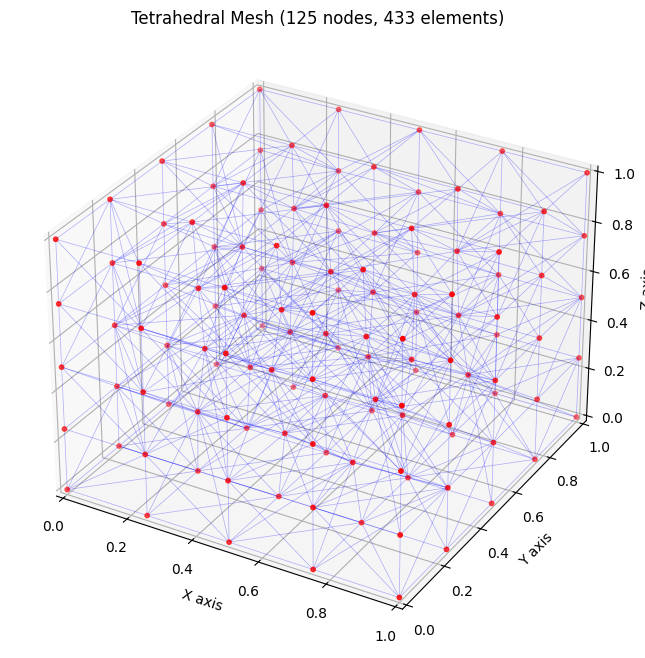

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

def plot_tet_mesh_matplotlib(P, T, alpha=0.3, node_size=10):
    """
    Visualizes a 3D tetrahedral mesh using Matplotlib.
    
    Parameters:
    P : ndarray of shape (N, 3) - Coordinates of the nodes
    T : ndarray of shape (M, 4) - Indices of the 4 nodes for each tetrahedron
    alpha : float - Transparency of the mesh lines
    node_size : int - Size of the red scatter points for nodes (set to 0 to hide)
    """
    # 1. A tetrahedron has 4 vertices. We extract all 6 possible edges.
    edges = np.vstack([
        T[:, [0, 1]], T[:, [0, 2]], T[:, [0, 3]],
        T[:, [1, 2]], T[:, [1, 3]], T[:, [2, 3]]
    ])
    
    # 2. Sort the node indices in each edge so that edge (i, j) is identical to (j, i)
    edges = np.sort(edges, axis=1)
    
    # 3. Find unique edges to avoid drawing the same line multiple times
    unique_edges = np.unique(edges, axis=0)
    
    # 4. Get the 3D coordinates for each edge. Shape becomes (num_unique_edges, 2, 3)
    edge_coords = P[unique_edges]
    
    # 5. Set up the plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Use Line3DCollection for fast rendering of many lines
    lc = Line3DCollection(edge_coords, colors='blue', linewidths=0.5, alpha=alpha)
    ax.add_collection(lc)
    
    # Plot the nodes as scatter points
    if node_size > 0:
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], color='red', s=node_size, depthshade=True)
        
    # Auto-scale limits (Line3DCollection doesn't automatically update bounding boxes)
    ax.set_xlim(P[:, 0].min(), P[:, 0].max())
    ax.set_ylim(P[:, 1].min(), P[:, 1].max())
    ax.set_zlim(P[:, 2].min(), P[:, 2].max())
    
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.set_title(f'Tetrahedral Mesh ({len(P)} nodes, {len(T)} elements)')
    
    plt.show()

# Example usage (assuming P and T are already loaded):
plot_tet_mesh_matplotlib(P[0], T_bad[0])

In [69]:
import pyvista as pv
import numpy as np

def plot_tet_mesh_pyvista(P, T):
    """
    Visualizes a 3D tetrahedral mesh using PyVista.
    """
    # PyVista requires a specific array format for unstructured grids:
    # [n_points, p1, p2, p3, p4, n_points, p1, p2, p3, p4, ...]
    # Since tetrahedra always have 4 points, we pad T with a column of 4s
    padding = np.full((T.shape[0], 1), 4, dtype=np.int64)
    cells = np.hstack([padding, T]).flatten()
    
    # VTK cell type for a tetrahedron is 10 (pv.CellType.TETRA)
    cell_types = np.full(T.shape[0], pv.CellType.TETRA, dtype=np.uint8)
    
    # Construct the PyVista UnstructuredGrid
    grid = pv.UnstructuredGrid(cells, cell_types, P)
    
    # Plot the mesh
    # show_edges=True draws the wireframe over the solid volumes
    grid.plot(show_edges=True, color='lightblue', opacity=0.5)

# Example usage:
plot_tet_mesh_pyvista(P[0], T_bad[0])

Widget(value='<iframe src="http://localhost:58166/index.html?ui=P_0x2c9b81c90_3&reconnect=auto" class="pyvista…

In [2]:
from tet_mat73_loader import TetMat73Dataset

ds = TetMat73Dataset("tet_dataset_grid125_sigma1e-02_N2000.mat", load_all=False)

print("Number of Samples in this Dataset:", ds.num_samples)
#this code just gets one sample from this dataset
P0, Tbad0 = ds.get(0)
print("P0 shape: ", P0.shape)
print("Tbad0 shape: ", Tbad0.shape)

T_good = ds.T_good
print("T_good shape:", T_good.shape)

ds.close()

Number of Samples in this Dataset: 2000
P0 shape:  (125, 3)
Tbad0 shape:  (433, 4)
T_good shape: (384, 4)


In [3]:
#this load everything
ds = TetMat73Dataset("tet_dataset_grid125_sigma1e-02_N2000.mat", load_all=True)
print("Points coordinates shape: ", ds.P.shape)         
print("Number of data points: ", len(ds.T_bad))     
print("Each topology shape: ", ds.T_bad[0].shape)
print("minQ_bad shape: ", ds.minQ_bad.shape)
print("minQ_good shape: ", ds.minQ_good.shape)

Points coordinates shape:  (2000, 125, 3)
Number of data points:  2000
Each topology shape:  (433, 4)
minQ_bad shape:  (2000,)
minQ_good shape:  (2000,)


### Try out the Env

In [2]:
from tet_mat73_loader import TetMat73Dataset
from tet_env import TetMeshRefineVecEnv
from tqdm.auto import tqdm

ds = TetMat73Dataset("tet_dataset_grid125_sigma1e-02_N2000.mat", load_all=False)

def make_mesh():
    i = np.random.randint(ds.num_samples)
    P, Tbad = ds.get(i)
    return P, Tbad

env = TetMeshRefineVecEnv(
    make_mesh_fn=make_mesh,
    num_envs=100,
    max_steps_per_episode=128,   # ✅ correct
    patience=30
)

obs = env.reset()

# random valid actions
for _ in tqdm(range(50)):
    acts = []
    for b in range(env.num_envs):
        mask = obs[b]["candidate_mask"]
        valid = np.flatnonzero(mask)
        acts.append(int(np.random.choice(valid)) if valid.size else 0)
    res = env.step(np.array(acts, dtype=np.int64))
    obs = res.obs
    print("reward mean:", res.reward.mean(), "done:", res.done.sum())


  0%|          | 0/50 [00:00<?, ?it/s]

reward mean: -0.00189378832123175 done: 0
reward mean: -0.001387053514227769 done: 0
reward mean: -0.001362830490094552 done: 0
reward mean: -0.0013380583954827935 done: 0
reward mean: -0.0013328723515451978 done: 0
reward mean: -0.0009597281192597728 done: 0
reward mean: -0.0009208099585769458 done: 0
reward mean: -0.0013369551917049034 done: 0
reward mean: -0.0006839482474367664 done: 0
reward mean: -0.0010886232535486037 done: 0
reward mean: -0.0008784759002850731 done: 0
reward mean: -0.0008426078163956114 done: 0
reward mean: -0.0008300800481353576 done: 0
reward mean: -0.0010737600827920894 done: 0
reward mean: -0.0010078461927945626 done: 0
reward mean: -0.0011128857486181257 done: 0
reward mean: -0.000833631215131777 done: 0
reward mean: -0.0008818671455199606 done: 0
reward mean: -0.0013109994925541819 done: 0
reward mean: -0.0010210577346759478 done: 0
reward mean: -0.0006387881234491644 done: 0
reward mean: -0.0008655957576947901 done: 0
reward mean: -0.0008816891110883616 d

# 3D Tet Mesh Flip RL: Code Walkthrough (Topology + Env)

This note explains the design and implementation of the two core modules:

- `tet_mesh_topology.py` — mesh state, adjacency, legal local flips, apply flips
- `tet_env.py` — vectorized RL environment wrapper (step/reset/reward/termination)

The goal is to mirror the structure of the 2D meshing agent, but for 3D tetrahedral meshes with **fixed vertex positions** and **topology-only** optimization.

---

## 1) `tet_mesh_topology.py` — What it is

Think of `TetMeshTopology3D` as the 3D equivalent of your 2D `MeshTopology`.

**Inputs**
- `P`: `(N, 3)` float — vertex coordinates (fixed during RL)
- `T`: `(K, 4)` int — tetra connectivity (changes during RL)

**Responsibilities**
1. Build adjacency (faces/edges → incident tets).
2. Compute per-tet quality.
3. Construct a **candidate action mask** of valid flips.
4. Apply a chosen action (local bistellar move) and update topology.

### Core invariants
- **Coordinates never change** inside the env.
- Only `T` changes via local flips.
- Every action is **local** (touching only 2 or 3 tets).

---

## 2) Tetrahedron quality metric (why + how)

The topology computes `tet_quality` for each tet (`shape = (K,)`) using a robust scale-invariant metric, typically **mean-ratio** quality:

\[
q = 12 \cdot (3V)^{2/3} \Big/ \sum_{6\ edges}\|e\|^2,
\quad q \in [0, 1]
\]

- `V` = tet volume
- denominator = sum of squared edge lengths
- equilateral tet → `q = 1`
- slivers / degenerate → near `0`

**Why mean-ratio**
- scale-invariant
- punishes slivers strongly
- stable numerically
- cheap to compute

---

## 3) Adjacency structures: faces and edges

### 3.1 Face adjacency (needed for 2–3 flips)

Each tet has 4 triangular faces. We build:

- `faces`: `(F, 3)` sorted vertex triples
- `face2tet`: `(F, 2)` incident tet ids
  - boundary face has second entry `-1`
- `face_opp`: `(F, 2)` the opposite vertex in each incident tet

**Why `face_opp` matters**
A 2–3 flip is defined by a shared face `(a,b,c)` between two tets:
- tet0 = `(a,b,c,d)`
- tet1 = `(a,b,c,e)`

You need the opposite vertices `d` and `e` to perform the flip.

---

### 3.2 Edge adjacency (needed for 3–2 flips)

Each tet has 6 edges. We build:

- `U_edge_index`: `(2, E)` endpoints `(u,v)` (sorted per edge)
- `edge2tet`: list length `E`, each entry is an array of incident tet ids
- `edge_deg`: `(E,)` edge valence (# incident tets)

**Why**
A 3–2 flip is defined around an internal edge `(u,v)` with **valence exactly 3**.

---

## 4) Action space design (face + edge actions)

We use a single discrete action index, like your 2D agent:

- actions `0 .. F-1`: pick a **face** → attempt **2–3 flip**
- actions `F .. F+E-1`: pick an **edge** → attempt **3–2 flip**

This keeps PPO simple:
- one categorical distribution
- one boolean mask `candidate_mask` of length `F+E`

Topology exposes:
- `candidate_face_mask`: `(F,)`
- `candidate_edge_mask`: `(E,)`
- `candidate_mask`: `(F+E,)` concatenation

---

## 5) Validity checks (how we define legal moves)

Correct validity is crucial: it prevents inverted/invalid meshes and stabilizes RL.

### 5.1 Valid 2–3 flip (face action)

A face flip is valid if:

1. The face is **internal**: `face2tet[f,1] != -1`
2. The new edge `(d,e)` does **not already exist** in the mesh
3. Geometry sanity: `d` and `e` lie on **opposite sides** of the face plane

The side test uses signed volumes (orientation test):

- compute sign of `det([b-a, c-a, d-a])` and similarly for `e`
- require product `< 0` (opposite sides)
- reject if either sign is 0 (degenerate)

---

### 5.2 Valid 3–2 flip (edge action)

An edge collapse is valid if:

1. Edge valence is exactly 3: `edge_deg[e] == 3`
2. The three incident tets define a **link triangle** `(a,b,c)`:
   - for each incident tet containing `(u,v)`, the other two vertices form an edge
   - across the 3 tets, those edges must form a triangle on 3 vertices
3. The face `(a,b,c)` does not already exist
4. Geometry sanity: `u` and `v` lie on opposite sides of plane `(a,b,c)`

Same signed-volume check is used for (4).

---

## 6) Applying flips (what topology changes)

### 6.1 2–3 flip

Given two tets sharing face `(a,b,c)` with opposite vertices `(d,e)`:

Remove:
- `(a,b,c,d)`
- `(a,b,c,e)`

Add:
- `(a,b,d,e)`
- `(b,c,d,e)`
- `(c,a,d,e)`

Then rebuild adjacency + qualities.

---

### 6.2 3–2 flip

Given valence-3 edge `(u,v)` with link triangle `(a,b,c)`:

Remove the 3 tets around `(u,v)`, add:

- `(a,b,c,u)`
- `(a,b,c,v)`

Then rebuild adjacency + qualities.

---

## 7) Features returned by topology

The topology provides simple local features to support a policy network:

### 7.1 `node_feat` (per vertex)

Typical signals:
- node degree in edge graph
- min/mean/max incident edge length (normalized by global mean edge length)
- min incident tet quality

This makes it easy for the policy/value net to find “bad regions”.

### 7.2 `action_feat` (per action element)

For faces:
- area (normalized)
- boundary flag
- flippable flag
- min incident tet quality

For edges:
- length (normalized)
- valence
- boundary flag
- flippable flag
- min incident tet quality

This mirrors the 2D design: attach local geometric context to each candidate action.

---

## 8) Rebuild strategy (correct-first)

This implementation rebuilds adjacency and candidate masks after every flip.

Why:
- simpler, less bug-prone
- fast enough for the toy dataset (125 vertices)
- gets PPO training running quickly

Later optimization:
- incremental updates only in the local neighborhood of the flip
- cached hash maps for faces/edges
- avoid recomputing everything per step

---

# 2) `tet_env.py` — RL environment wrapper

`TetMeshRefineVecEnv` is the 3D analogue of your 2D vectorized environment.

It runs `num_envs` independent meshes in parallel and implements:

- `reset()`: sample fresh mesh for each env
- `step(actions)`: apply one action per env, compute reward, check termination, auto-reset done envs

---

## 1) Reward design

### Mesh score
Instead of using `min(tet_quality)` directly (too sparse/noisy), we use a smoother proxy:

**worst-k mean**:
- take worst `k` tet qualities
- score = mean of those `k`

Reward:
\[
r = \text{reward\_scale} \cdot (\text{score}_{t+1} - \text{score}_t)
\]

Optional:
- invalid action penalty (if action not in mask)

Why worst-k mean:
- still targets slivers and poor regions
- provides smoother learning signal than raw min

---

## 2) Termination conditions

An episode ends if any is true:

- no valid actions remain (`candidate_mask` all false)
- step limit reached (`max_steps_per_episode`)
- no improvement for `patience` steps (stagnation)

This matches the 2D agent’s “stuck / no moves / too long” logic.

Done envs are auto-reset to new samples.

---

## 3) Observation dict returned

Each env returns a dict containing:

- `points`, `tets`
- `faces`, `face2tet`, `U_edge_index`
- `candidate_mask` (critical for PPO masking)
- `node_feat`, `action_feat`
- `tet_quality`

It’s intentionally “raw + rich” so you can choose your network encoder:
- GNN / EGNN on vertices
- action-wise attention over faces+edges
- pooled local neighborhood features, etc.

---

# 3) Mapping from your 2D agent to 3D

Same high-level pattern:

- 2D: action = choose edge → flip (2 tris ↔ 2 tris)
- 3D: action = choose face or edge → flip (2–3 or 3–2)

But interface stays identical:
- one discrete action index
- one candidate mask
- local geometric features attached to actions

This makes PPO integration straightforward.

---

## Suggested reading order (to get familiar fast)

### In `tet_mesh_topology.py`
1. `rebuild()`
2. `_build_faces()`, `_build_edges()`
3. `_build_candidate_masks()`
4. `apply_action()`, `_flip_2_3()`, `_flip_3_2()`

### In `tet_env.py`
1. `_score()`
2. `step()`
3. termination logic + auto-reset behavior

---


In [1]:
import numpy as np
import torch
from tqdm.auto import tqdm

from tet_mat73_loader import TetMat73Dataset
from tet_env import TetMeshRefineVecEnv

from model_face_edge_gpt import Mesh3DActorCritic
from initial_embedding import batch_from_obs, model_action_to_env_with_sizes

ds = TetMat73Dataset("tet_dataset_grid125_sigma1e-02_N2000.mat", load_all=False)

def make_mesh():
    i = np.random.randint(ds.num_samples)
    P, Tbad = ds.get(i)
    return P, Tbad

env = TetMeshRefineVecEnv(
    make_mesh_fn=make_mesh,
    num_envs=100,
    max_steps_per_episode=128,
    patience=30
)

obs = env.reset()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build one batch to infer input feature dims
bg0 = batch_from_obs(obs, device=device, num_fourier_freqs=6)
d_edge_in = bg0.edge_feat.shape[-1]
d_face_in = bg0.face_feat.shape[-1]
print("initial edge feature dim: ", d_edge_in)
print("initial face feature dim: ", d_face_in)

model = Mesh3DActorCritic(
    d_edge_in=d_edge_in,
    d_face_in=d_face_in,
    d_h=128,
    num_layers=4,
    msg_hidden=128,
    use_coord_update=False,
    dropout=0.0,
    head_hidden=128,
    value_hidden=128,
).to(device)
model.eval()

for _ in tqdm(range(50)):
    bg = batch_from_obs(obs, device=device, num_fourier_freqs=6)

    with torch.no_grad():
        policy_out, value, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits  # (B, Emax+Fmax) in MODEL ordering [edges, faces]
        dist = torch.distributions.Categorical(logits=logits)
        a_model = dist.sample().cpu().numpy()  # (B,)

    # sizes per env
    E_sizes = np.array([o["edges"].shape[1] for o in obs], dtype=np.int64)
    F_sizes = np.array([o["faces"].shape[0] for o in obs], dtype=np.int64)

    # Fix invalid samples (padded or masked) by resampling from env's valid set
    a_model_fixed = []
    for b in range(env.num_envs):
        E = int(E_sizes[b]); F = int(F_sizes[b])
        cand = obs[b]["candidate_mask"]          # ENV ordering [faces, edges]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)

        # valid in MODEL ordering [edges, faces]
        valid_model = np.concatenate([
            np.flatnonzero(cand_edge),           # edges in [0..E-1]
            E + np.flatnonzero(cand_face)        # faces in [E..E+F-1]
        ], axis=0)

        if valid_model.size == 0:
            a_model_fixed.append(0)
            continue

        a = int(a_model[b])
        if a >= (E + F) or (a not in set(valid_model.tolist())):
            a = int(np.random.choice(valid_model))
        a_model_fixed.append(a)

    a_model_fixed = np.array(a_model_fixed, dtype=np.int64)

    # Map MODEL -> ENV action index
    acts_env = model_action_to_env_with_sizes(a_model_fixed, E_sizes, F_sizes)

    res = env.step(acts_env)
    obs = res.obs
    print("reward mean:", res.reward.mean(), "done:", res.done.sum())

initial edge feature dim:  49
initial face feature dim:  51


  0%|          | 0/50 [00:00<?, ?it/s]

reward mean: -0.0014793058573503923 done: 0
reward mean: -0.0011403831558735242 done: 0
reward mean: -0.001115452830656618 done: 0
reward mean: -0.0011478080737733565 done: 0
reward mean: -0.0007102326331232947 done: 0
reward mean: -0.0005792169544977513 done: 0
reward mean: -0.000904668081950995 done: 0
reward mean: -0.0008429656964660609 done: 0
reward mean: -0.0012851173262144132 done: 0
reward mean: -0.0012567167976115891 done: 0
reward mean: -0.0007166063930087505 done: 0
reward mean: -0.0005511786678298705 done: 0
reward mean: -0.0009010890031312965 done: 0
reward mean: -0.0005125359298672827 done: 0
reward mean: -0.0007771290450345661 done: 0
reward mean: -0.0007528093120109447 done: 0
reward mean: -0.0006321129467627948 done: 0
reward mean: -0.000680116360185165 done: 0
reward mean: -0.0007448779286826996 done: 0
reward mean: -0.0006533258004755329 done: 0
reward mean: -0.00032678366054584684 done: 0
reward mean: -0.0005609258332917874 done: 0
reward mean: -0.000390863412655454

# Initial Embedding for 3D Tet Mesh RL (Edge–Face Bipartite Graph)

This notebook documents the **initial embedding design** used by `initial_embedding.py` for the 3D tetrahedral mesh refinement RL project.

We model the mesh as a **bipartite graph** with two node types:

- **Edge nodes**: one node per mesh edge (2 vertices).
- **Face nodes**: one node per mesh triangular face (3 vertices).

Edges in this bipartite graph represent **incidence**:
- A **face node** connects only to its **3 incident edge nodes**.
- An **edge node** connects only to the **faces** that contain it.

The goal of the embedding is to supply the GNN (EGNN backbone) with:
1. **Geometric information** (shape/quality) that is **E(3)-invariant** (translation/rotation invariant).
2. **Topological information** (connectivity/valence/incidence) that reflects local structure.
3. A representation that is **numerically stable** across meshes with different scales.

---

## 1. Coordinate Input to EGNN (Invariant features + Equivariant coordinates)

The EGNN backbone uses node coordinates `x` (for equivariant message passing) and node features `h` (invariant features).

We assign coordinates as:

### Edge node coordinate
For edge \( e = (u,v) \) with endpoints \(p_u, p_v \in \mathbb{R}^3\):

\[
x_e = \frac{p_u + p_v}{2}
\]

**Interpretation:** the edge node sits at the edge midpoint.

### Face node coordinate
For face \( f = (i,j,k) \) with vertices \(p_i, p_j, p_k\):

\[
x_f = \frac{p_i + p_j + p_k}{3}
\]

**Interpretation:** the face node sits at the triangle centroid.

> These coordinates are **translation/rotation equivariant**, which is appropriate for EGNN.
> The **feature embeddings** described below are built to be **E(3)-invariant**, so the network sees stable geometry signals.

---

## 2. Global Scale Normalization

Raw lengths/areas vary widely between meshes. We normalize them to improve generalization and stabilize training.

### Mesh scale
Let \(\ell_e\) be the length of every edge in the mesh. Define:

\[
s = \mathrm{median}_e(\ell_e)
\]

We then normalize:
- Edge length as \(\ell_e / s\)
- Face area as \(A_f / s^2\)

We also take **log** of normalized quantities for numerical stability (avoids large dynamic ranges).

---

## 3. Fourier Feature Encoding for Continuous Scalars

Continuous scalars like `log-length`, `log-area`, and angles are encoded using Fourier features.

Given a scalar \(x\), define:

\[
\mathrm{FF}(x) =
\Big[
x, \sin(2^0 x), \cos(2^0 x),
\sin(2^1 x), \cos(2^1 x),
\ldots,
\sin(2^{F-1} x), \cos(2^{F-1} x)
\Big]
\]

where \(F\) is the number of frequencies (e.g. `num_fourier_freqs=6`).

**Why Fourier features?**
- Improves expressive power for MLP embeddings.
- Helps the network represent thresholds and periodic patterns (angles).
- Works well for value heads and policy logits.

---

## 4. Degree / Incidence Encoding for Discrete Counts

Discrete counts like vertex degree or incidence (#faces around an edge) are encoded as **bucketed one-hot vectors**.

Example bins (configurable):
- Degree bins: \([1,2,3,4,6,8,12,20,40]\)
- Incidence bins: \([0,1,2,3,4,6,8,12,20]\)

Given an integer count \(c\), we compute its bin index and generate a one-hot vector.

**Why bucketed one-hot?**
- Degrees/incidences can have outliers.
- One-hot avoids the model treating degree as a purely linear quantity.
- Buckets give robustness across different mesh densities.

---

## 5. Edge Node Feature Vector (What goes into `edge_feat`)

For each edge \(e = (u,v)\), we construct:

### 5.1 Normalized log-length (Fourier encoded)
- Edge length: \(\ell_e = \|p_u - p_v\|\)
- Normalized: \(\ell_e/s\)
- Log: \(\log(\ell_e/s)\)
- Then encode with Fourier features: \(\mathrm{FF}(\log(\ell_e/s))\)

This captures **local geometric scale** of the edge.

### 5.2 Endpoint vertex degrees (bucketed one-hot)
We compute vertex degrees from the edge list:
\[
\deg(u) = \#\{\text{edges incident to }u\}, \quad \deg(v)=\#\{\text{edges incident to }v\}
\]

Then encode each using degree buckets:
\[
\mathrm{OH}(\deg(u)),\ \mathrm{OH}(\deg(v))
\]

This captures **local connectivity** around endpoints.

### 5.3 Edge incidence: number of faces containing the edge (bucketed one-hot)
\[
\#\mathrm{faces}(e) = \#\{\text{triangle faces containing } e\}
\]
Encode as \(\mathrm{OH}(\#\mathrm{faces}(e))\).

This captures **whether the edge is boundary/interior**:
- boundary edges usually have fewer incident faces than interior edges,
- but we *do not* include an explicit boundary flag (to avoid redundancy).

### 5.4 Edge incidence: number of tetrahedra containing the edge (bucketed one-hot)
\[
\#\mathrm{tets}(e) = \#\{\text{tets containing } e\}
\]
Encode as \(\mathrm{OH}(\#\mathrm{tets}(e))\).

This captures **3D interior structure** (edge valence in tetrahedra), crucial for deciding flips.

### Final edge feature (conceptual)
\[
h^{(0)}_e =
\Big[
\mathrm{FF}(\log(\ell_e/s)),
\mathrm{OH}(\deg(u)),
\mathrm{OH}(\deg(v)),
\mathrm{OH}(\#\mathrm{faces}(e)),
\mathrm{OH}(\#\mathrm{tets}(e))
\Big]
\]

---

## 6. Face Node Feature Vector (What goes into `face_feat`)

For each face \(f=(i,j,k)\), we compute geometric properties of the triangle.

### 6.1 Normalized log-area (Fourier encoded)
Area:
\[
A_f = \frac12 \| (p_j-p_i)\times(p_k-p_i) \|
\]
Normalize:
\[
A_f/s^2
\]
Log:
\[
\log(A_f/s^2)
\]
Encode:
\[
\mathrm{FF}(\log(A_f/s^2))
\]

Captures triangle size in a scale-robust way.

### 6.2 Triangle angles (shape; Fourier encoded)
Compute the three edge lengths (normalized by \(s\)):
\[
\ell_{ij},\ \ell_{jk},\ \ell_{ki}
\]
Use cosine law to compute angles \(\theta_1,\theta_2,\theta_3\), then sort:
\[
\theta_{\min} \le \theta_{\mathrm{mid}} \le \theta_{\max}
\]
Encode each with Fourier features.

**Why angles?**
- Strong signal for skinny/degenerate faces.
- Directly correlates with mesh quality metrics.

### 6.3 Aspect ratio (degeneracy indicator; Fourier encoded)
Aspect ratio:
\[
\mathrm{asp}_f = \frac{\ell_{\max}}{\ell_{\min}}
\]
Use log:
\[
\log(\mathrm{asp}_f)
\]
Encode with Fourier features.

Captures thin/sliver triangles.

### 6.4 Area-shape normalization (dimensionless; Fourier encoded)
Define mean edge length:
\[
\bar{\ell} = \frac{\ell_{ij} + \ell_{jk} + \ell_{ki}}{3}
\]
Define a dimensionless shape statistic:
\[
\mathrm{shape}_f = \frac{A_f/s^2}{(\bar{\ell}/s)^2}
\]
Use log and Fourier encode:
\[
\mathrm{FF}(\log(\mathrm{shape}_f))
\]

This helps distinguish triangles that have the same aspect ratio but different “compactness”.

### 6.5 Face incidence: number of tets sharing the face (one-hot)
From `face2tet`, each face is shared by 1 or 2 tetrahedra (boundary vs interior).
We encode:
\[
\mathrm{OH}(\#\mathrm{tets}(f))
\]
where \(\#\mathrm{tets}(f)\in\{1,2\}\).

> We removed the explicit boundary flag because it is redundant with this incidence count.

### Final face feature (conceptual)
\[
h^{(0)}_f =
\Big[
\mathrm{FF}(\log(A_f/s^2)),
\mathrm{FF}(\theta_{\min}),
\mathrm{FF}(\theta_{\mathrm{mid}}),
\mathrm{FF}(\theta_{\max}),
\mathrm{FF}(\log(\mathrm{asp}_f)),
\mathrm{FF}(\log(\mathrm{shape}_f)),
\mathrm{OH}(\#\mathrm{tets}(f))
\Big]
\]

---

## 7. Incidence Graph Construction (`edge_index`)

We build directed edges between edge nodes and face nodes based on incidence:

For each face \(f=(i,j,k)\), its three edges are:
- \((i,j)\), \((j,k)\), \((i,k)\)

For each of these edges \(e\), we add **two directed edges**:
- edge → face
- face → edge

This results in a bipartite graph where:
- face nodes only connect to their 3 edges,
- edge nodes connect to all faces that contain them.

---

## 8. Candidate Masks and Action Ordering

### Environment action ordering (from `tet_env.py`)
The env action space is:
\[
[\text{faces first} \ \Vert\ \text{edges second}]
\]
So `candidate_mask` has length \(F+E\) and is:
- first \(F\): valid face-actions
- last \(E\): valid edge-actions

### Model action ordering (used by `Mesh3DActorCritic`)
The model logits are ordered as:
\[
[\text{edges first} \ \Vert\ \text{faces second}]
\]
So the batch builder splits env mask into:
- `face_action_mask` = first \(F\)
- `edge_action_mask` = last \(E\)

and the policy head assembles logits as:
- `[edge_logits, face_logits]`

A helper is provided to map sampled actions back:
- model edge action `a < E` → env index `F + a`
- model face action `a >= E` → env index `a - E`

---

## 9. Summary Table

| Node Type | Coordinates for EGNN | Invariant Features |
|----------:|----------------------|-------------------|
| Edge node | midpoint \((p_u+p_v)/2\) | log-length (Fourier), endpoint degrees (bucket OH), #incident faces (bucket OH), #incident tets (bucket OH) |
| Face node | centroid \((p_i+p_j+p_k)/3\) | log-area (Fourier), sorted angles (Fourier), log-aspect (Fourier), log-shape-area (Fourier), #incident tets (one-hot) |

---

## 10. Why this embedding is “sufficient” for RL

This embedding gives the policy and critic:
- Strong signals for **bad geometry** (skinny faces, extreme aspect, tiny areas),
- Signals for **topological neighborhood complexity** (degrees, incidences),
- Scale-invariance across meshes,
- E(3)-invariance for features (coordinates are handled equivariantly by EGNN).

This is usually enough for PPO to learn which local structures to repair (by edge/face actions) even before adding any flip-specific handcrafted features.

In [1]:
import os
import re
import glob
import numpy as np
import torch
from tqdm.auto import tqdm

from tet_mesh_topology import TetMeshTopology
from tet_env import softmin_score, worstk_mean_score

from tet_mat73_loader import TetMat73Dataset

from model_face_edge_gpt import Mesh3DActorCritic
from initial_embedding import batch_from_obs, model_action_to_env_with_sizes


# ----------------------------
# Helpers: score + obs format
# ----------------------------

def score_mesh(topo: TetMeshTopology, mode: str = "softmin", tau: float = 0.05, worstk_k: int = 10) -> float:
    q = topo.tet_quality
    if mode == "softmin":
        return softmin_score(q, tau=tau)
    elif mode == "worstk":
        return worstk_mean_score(q, k=worstk_k)
    else:
        raise ValueError(f"Unknown score mode: {mode}")


def obs_from_topo(topo: TetMeshTopology) -> dict:
    """
    Must match TetMeshRefineVecEnv._obs() exactly.
    """
    return dict(
        points=topo.points,
        tets=topo.tets,
        faces=topo.faces,
        face2tet=topo.face2tet,
        edges=topo.edges,
        candidate_mask=topo.candidate_mask(),
        tet_quality=topo.tet_quality,
    )


def find_latest_checkpoint(out_dir: str = "out") -> str:
    ckpts = glob.glob(os.path.join(out_dir, "model_round*.pt"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found in {out_dir}/model_round*.pt")

    def round_id(p):
        m = re.search(r"model_round(\d+)\.pt", os.path.basename(p))
        return int(m.group(1)) if m else -1

    ckpts.sort(key=round_id)
    return ckpts[-1]


def load_checkpoint_model(ckpt_path: str, device: torch.device, example_obs_list: list) -> Mesh3DActorCritic:
    """
    Builds model with correct input dims inferred from example obs, then loads state_dict.
    """
    bg0 = batch_from_obs(example_obs_list, device=device)
    d_edge_in = bg0.edge_feat.shape[-1]
    d_face_in = bg0.face_feat.shape[-1]

    model = Mesh3DActorCritic(
        d_edge_in=d_edge_in,
        d_face_in=d_face_in,
        d_h=128,
        num_layers=4,
        msg_hidden=128,
        value_hidden=128,
        use_coord_update=False,
        dropout=0.2,  # must match training
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model" in ckpt:
        sd = ckpt["model"]
    else:
        # support plain state_dict saved via torch.save(model.state_dict())
        sd = ckpt

    model.load_state_dict(sd, strict=True)
    model.eval()
    return model


# ----------------------------------------
# Helper: try to get "good mesh" reference
# ----------------------------------------

def try_get_good_mesh(ds: TetMat73Dataset, i: int):
    """
    Best-effort support for multiple dataset APIs.

    We try, in order:
      1) ds.get(i) returns (P, Tbad, Tgood)
      2) ds.get(i) returns dict with keys {"P","Tbad","Tgood"} or similar
      3) ds.get_good(i) returns (P, Tgood)
      4) ds.good_tets[i] style attributes

    Returns:
      (P_good, T_good) if available, else None
    """
    # 1) tuple length 3
    out = ds.get(i)
    if isinstance(out, (tuple, list)) and len(out) >= 3:
        P, Tbad, Tgood = out[0], out[1], out[2]
        if Tgood is not None:
            return P, Tgood

    # 2) dict-like
    if isinstance(out, dict):
        # common key variants
        P = out.get("P", out.get("points", None))
        Tgood = out.get("Tgood", out.get("good_tets", out.get("T_ref", None)))
        if P is not None and Tgood is not None:
            return P, Tgood

    # 3) ds.get_good(i)
    if hasattr(ds, "get_good"):
        try:
            P, Tgood = ds.get_good(i)
            return P, Tgood
        except Exception:
            pass

    # 4) attribute arrays
    for key in ["Tgood", "good_tets", "tets_good", "T_ref", "ref_tets"]:
        if hasattr(ds, key):
            try:
                Tgood_all = getattr(ds, key)
                P, _ = ds.get(i)[:2] if isinstance(ds.get(i), (tuple, list)) else (None, None)
                if P is None and hasattr(ds, "P"):
                    P = getattr(ds, "P")[i]
                if Tgood_all is not None:
                    return P, Tgood_all[i]
            except Exception:
                pass

    return None


# ----------------------------
# Main evaluation loop
# ----------------------------

@torch.inference_mode()
def run_agent_until_stall(
    topo: TetMeshTopology,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    score_mode: str = "softmin",
    softmin_tau: float = 0.05,
    worstk_k: int = 10,
    eps_improve: float = 1e-6,
    patience_eval: int = 50,
    max_steps: int = 500,
    greedy: bool = True,
):
    """
    Runs greedy policy until:
      - no valid moves remain OR
      - no improvement for patience_eval steps OR
      - steps reach max_steps

    IMPORTANT: topo.apply_action expects ENV action indexing:
        [faces first then edges]
    while model outputs logits in MODEL ordering:
        [edges first then faces]
    We map using model_action_to_env_with_sizes().
    """
    best_score = score_mesh(topo, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)
    no_improve = 0
    steps = 0

    history = []
    history.append(best_score)

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(topo)
        bg = batch_from_obs([obs], device=device)

        policy_out, value, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]  # (Emax+Fmax,)

        # True sizes for mapping
        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]

        # Determine valid actions in MODEL ordering:
        # env candidate ordering is [faces, edges]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)], axis=0)

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)

        # Choose action in MODEL ordering
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            # sample from restricted distribution
            sub_logits = logits[valid_model_t]
            dist = torch.distributions.Categorical(logits=sub_logits)
            idx = int(dist.sample().item())
            a_model = valid_model[idx]

        # map to ENV ordering and apply
        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        score_before = score_mesh(topo, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)
        ok = topo.apply_action(int(a_env))
        score_after = score_mesh(topo, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)

        # If action was invalid (should rarely happen if masks are consistent), treat as no-improve
        if not ok:
            no_improve += 1
        else:
            if (score_after - best_score) >= eps_improve:
                best_score = score_after
                no_improve = 0
            else:
                no_improve += 1

        history.append(score_after)
        steps += 1

        if no_improve >= patience_eval:
            break

    final_score = score_mesh(topo, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)
    return dict(
        steps=steps,
        best_score=best_score,
        final_score=final_score,
        history=np.array(history, dtype=np.float64),
        stalled=(no_improve >= patience_eval),
        no_moves=(not np.any(topo.candidate_mask())),
    )


def main():
    # ----------------------------
    # Settings
    # ----------------------------
    dataset_path = "tet_dataset_grid125_sigma1e-02_N2000.mat"
    out_dir = "out"
    ckpt = None  # set to a path like "out/model_round19.pt" to force
    num_test = 50
    seed = 0

    # Evaluation stopping
    patience_eval = 80
    max_steps = 800
    eps_improve = 1e-6

    # Score (must match what you care about)
    score_mode = "softmin"     # or "worstk"
    softmin_tau = 0.05
    worstk_k = 10

    greedy = True  # deterministic evaluation

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    # ----------------------------
    # Load dataset
    # ----------------------------
    ds = TetMat73Dataset(dataset_path, load_all=False)

    rng = np.random.default_rng(seed)
    indices = rng.integers(low=0, high=ds.num_samples, size=num_test, dtype=np.int64)

    # ----------------------------
    # Pick checkpoint
    # ----------------------------
    if ckpt is None:
        ckpt = find_latest_checkpoint(out_dir)
    print("Using checkpoint:", ckpt)

    # Need one example obs to build model dims
    P0, T0 = ds.get(int(indices[0]))[:2]
    topo0 = TetMeshTopology(P0, T0)
    model = load_checkpoint_model(ckpt, device, [obs_from_topo(topo0)])

    # ----------------------------
    # Evaluate
    # ----------------------------
    bad_scores = []
    agent_final_scores = []
    agent_best_scores = []
    good_scores = []  # may contain NaN if unavailable
    steps_used = []

    for i in tqdm(indices, desc="Evaluating"):
        i = int(i)

        out = ds.get(i)
        if isinstance(out, (tuple, list)):
            P, Tbad = out[0], out[1]
        elif isinstance(out, dict):
            P = out.get("P", out.get("points"))
            Tbad = out.get("Tbad", out.get("tets_bad", out.get("T", None)))
            if Tbad is None:
                raise ValueError("Dataset dict does not contain bad tets.")
        else:
            raise ValueError("Unsupported dataset get(i) output type.")

        topo_bad = TetMeshTopology(P, Tbad)
        s_bad = score_mesh(topo_bad, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)

        # run agent
        topo_agent = TetMeshTopology(P, Tbad.copy())
        res = run_agent_until_stall(
            topo_agent,
            model,
            device,
            score_mode=score_mode,
            softmin_tau=softmin_tau,
            worstk_k=worstk_k,
            eps_improve=eps_improve,
            patience_eval=patience_eval,
            max_steps=max_steps,
            greedy=greedy,
        )
        s_final = res["final_score"]
        s_best = res["best_score"]

        # good mesh reference (if available)
        ref = try_get_good_mesh(ds, i)
        if ref is None or ref[1] is None:
            s_good = np.nan
        else:
            P_good, T_good = ref
            topo_good = TetMeshTopology(P_good, T_good)
            s_good = score_mesh(topo_good, mode=score_mode, tau=softmin_tau, worstk_k=worstk_k)

        bad_scores.append(s_bad)
        agent_final_scores.append(s_final)
        agent_best_scores.append(s_best)
        good_scores.append(s_good)
        steps_used.append(res["steps"])

    bad_scores = np.array(bad_scores, dtype=np.float64)
    agent_final_scores = np.array(agent_final_scores, dtype=np.float64)
    agent_best_scores = np.array(agent_best_scores, dtype=np.float64)
    good_scores = np.array(good_scores, dtype=np.float64)
    steps_used = np.array(steps_used, dtype=np.int64)

    print("\n================= Summary =================")
    print(f"Score mode: {score_mode}  (tau={softmin_tau}  worstk_k={worstk_k})")
    print(f"Samples: {num_test}")
    print(f"Avg steps used: {steps_used.mean():.1f} (max {steps_used.max()})")

    print("\n--- Bad mesh ---")
    print(f"mean {bad_scores.mean():.6f} | std {bad_scores.std():.6f}")

    print("\n--- Agent final ---")
    print(f"mean {agent_final_scores.mean():.6f} | std {agent_final_scores.std():.6f}")
    print(f"mean improvement (final - bad): {(agent_final_scores - bad_scores).mean():.6f}")

    print("\n--- Agent best-in-run ---")
    print(f"mean {agent_best_scores.mean():.6f} | std {agent_best_scores.std():.6f}")
    print(f"mean improvement (best - bad): {(agent_best_scores - bad_scores).mean():.6f}")

    if np.isfinite(good_scores).any():
        mask = np.isfinite(good_scores)
        print("\n--- Good reference mesh ---")
        print(f"mean {good_scores[mask].mean():.6f} | std {good_scores[mask].std():.6f}")
        print("\n--- Gap to good (agent_best - good) ---")
        print(f"mean {(agent_best_scores[mask] - good_scores[mask]).mean():.6f} | "
              f"median {np.median(agent_best_scores[mask] - good_scores[mask]):.6f}")
        print("\n--- % reaching / exceeding good ---")
        print(f"{100.0 * np.mean(agent_best_scores[mask] >= good_scores[mask]):.2f}%")
    else:
        print("\n(No good reference mesh found in dataset API; good_scores are NaN.)")
        print("If your dataset has a different access method for 'good mesh', tell me the API and I’ll wire it in.")

    print("==========================================\n")


if __name__ == "__main__":
    main()

device: cpu
Using checkpoint: out/model_round19.pt


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


================= Summary =================
Score mode: softmin  (tau=0.05  worstk_k=10)
Samples: 50
Avg steps used: 121.8 (max 146)

--- Bad mesh ---
mean 0.228000 | std 0.013812

--- Agent final ---
mean 0.304603 | std 0.026872
mean improvement (final - bad): 0.076603

--- Agent best-in-run ---
mean 0.307194 | std 0.026664
mean improvement (best - bad): 0.079194

(No good reference mesh found in dataset API; good_scores are NaN.)
If your dataset has a different access method for 'good mesh', tell me the API and I’ll wire it in.



# RL Agent Test on Tet Dataset (Bad vs Agent vs Good)

This notebook evaluates a trained RL agent checkpoint `out/model_round*.pt` on the dataset:

- Each sample provides point coordinates `P` and a "bad" Delaunay tetrahedralization `T_bad`.
- The dataset also stores a *constant* "good topology" `T_good` (computed once on the unperturbed grid),
  and its quality is evaluated on the *same* perturbed points `P`.

For each test sample we compute and compare:
- `q_bad  = simpqual(P, T_bad)`  (via `TetMeshTopology`)
- `q_good = simpqual(P, T_good)` (same P, fixed T_good)
- `q_agent` after running the RL policy until improvement stalls.

We compare the *quality sequences* by sorting per-tet qualities:
- `sort(q_bad)`, `sort(q_agent)`, `sort(q_good)`
and also compare summary metrics like `min`, `worst-k mean`, and `softmin`.

In [1]:
import os
import re
import glob
import numpy as np
import torch
from tqdm.auto import tqdm

from tet_mat73_loader import TetMat73Dataset
from tet_mesh_topology import TetMeshTopology
from tet_env import softmin_score, worstk_mean_score

from model_face_edge_gpt import Mesh3DActorCritic
from initial_embedding import batch_from_obs, model_action_to_env_with_sizes

In [2]:
def round_id_from_ckpt(path: str) -> int:
    m = re.search(r"model_round(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


def pick_checkpoints(run_dir: str, round_ids=None, include_final=False):
    """
    Return a sorted list of checkpoint paths from one out_* directory.

    If round_ids is None, pick a spread of rounds.
    """
    ckpts = sorted(
        glob.glob(os.path.join(run_dir, "model_round*.pt")),
        key=round_id_from_ckpt,
    )
    if not ckpts:
        raise FileNotFoundError(f"No model_round*.pt found in {run_dir}")

    if round_ids is None:
        ids = [round_id_from_ckpt(p) for p in ckpts]
        rmax = max(ids)
        # Evaluate a clear progression across training.
        want = sorted(set([0, rmax // 4, rmax // 2, (3 * rmax) // 4, rmax]))
    else:
        want = sorted(set(int(x) for x in round_ids))

    picked = []
    by_id = {round_id_from_ckpt(p): p for p in ckpts}
    for rid in want:
        if rid in by_id:
            picked.append(by_id[rid])

    if include_final:
        final_path = os.path.join(run_dir, "model_final.pt")
        if os.path.exists(final_path):
            picked.append(final_path)

    if not picked:
        raise RuntimeError("No checkpoints matched selection.")
    return picked


def obs_from_topo(
    topo: TetMeshTopology,
    *,
    step: int,
    no_improve: int,
    max_steps: int,
    patience_eval: int,
) -> dict:
    # Must match training observation keys with added progress fields.
    return dict(
        points=topo.points,
        tets=topo.tets,
        faces=topo.faces,
        face2tet=topo.face2tet,
        edges=topo.edges,
        candidate_mask=topo.candidate_mask(),
        tet_quality=topo.tet_quality,
        step_frac=float(step) / float(max(1, max_steps)),
        no_improve_frac=float(no_improve) / float(max(1, patience_eval)),
    )


def score_from_quality(q: np.ndarray, score_mode: str, softmin_tau: float, worstk_k: int) -> float:
    if score_mode == "softmin":
        return softmin_score(q, tau=softmin_tau)
    if score_mode == "worstk":
        return worstk_mean_score(q, k=worstk_k)
    raise ValueError(score_mode)


def build_model_from_ckpt(ckpt_path: str, device: torch.device, example_obs: dict):
    """
    Build model with architecture from checkpoint run_config when available.
    Supports old and new checkpoints.
    """
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model" in ckpt:
        state = ckpt["model"]
        cfg = ckpt.get("run_config", {})
    else:
        state = ckpt
        cfg = {}

    bg0 = batch_from_obs([example_obs], device=device)
    d_edge_in = bg0.edge_feat.shape[-1]
    d_face_in = bg0.face_feat.shape[-1]

    model = Mesh3DActorCritic(
        d_edge_in=d_edge_in,
        d_face_in=d_face_in,
        d_h=int(cfg.get("d_h", 128)),
        num_layers=int(cfg.get("num_layers", 4)),
        msg_hidden=int(cfg.get("msg_hidden", 128)),
        value_hidden=int(cfg.get("value_hidden", 128)),
        critic_extra_dim=int(cfg.get("critic_extra_dim", bg0.quality_feat.shape[-1])),
        use_coord_update=False,
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(device)

    model.load_state_dict(state, strict=True)
    model.eval()
    return model



In [3]:
@torch.inference_mode()
def run_agent_until_stall(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
):
    topo = TetMeshTopology(P, T_init.copy())

    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
    best = cur
    no_improve = 0
    steps = 0
    step_rewards = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        step_rewards.append(float(cur - prev))

        if ok and (cur - best) >= eps_improve:
            best = cur
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    final_score = cur
    return topo, best, final_score, steps, step_rewards


def evaluate_checkpoint(
    ckpt_path: str,
    ds: TetMat73Dataset,
    test_ids: np.ndarray,
    T_good: np.ndarray,
    device: torch.device,
    *,
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    patience_eval=80,
    max_steps=800,
    greedy=True,
):
    i0 = int(test_ids[0])
    P0, Tbad0 = ds.get(i0)
    topo0 = TetMeshTopology(P0, Tbad0)
    model = build_model_from_ckpt(
        ckpt_path,
        device,
        obs_from_topo(topo0, step=0, no_improve=0, max_steps=max_steps, patience_eval=patience_eval),
    )

    rows = []
    step_reward_trajs = []
    for i in tqdm(test_ids, desc=f"Eval {os.path.basename(ckpt_path)}", leave=False):
        P, Tbad = ds.get(int(i))

        topo_bad = TetMeshTopology(P, Tbad)
        score_bad = score_from_quality(topo_bad.tet_quality, score_mode, softmin_tau, worstk_k)

        topo_good = TetMeshTopology(P, T_good)
        score_good = score_from_quality(topo_good.tet_quality, score_mode, softmin_tau, worstk_k)

        _, score_best, score_final, steps, step_rewards = run_agent_until_stall(
            P,
            Tbad,
            model,
            device,
            score_mode=score_mode,
            softmin_tau=softmin_tau,
            worstk_k=worstk_k,
            patience_eval=patience_eval,
            max_steps=max_steps,
            greedy=greedy,
        )

        rows.append((score_bad, score_final, score_best, score_good, steps))
        step_reward_trajs.append(step_rewards)

    arr = np.asarray(rows, dtype=np.float64)

    max_len = max((len(tr) for tr in step_reward_trajs), default=0)
    step_reward_mean = np.full(max_len, np.nan, dtype=np.float64)
    step_reward_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [tr[t] for tr in step_reward_trajs if t < len(tr)]
        if vals:
            step_reward_mean[t] = float(np.mean(vals))
            step_reward_count[t] = int(len(vals))

    return dict(
        ckpt=ckpt_path,
        round_id=round_id_from_ckpt(ckpt_path),
        n=len(rows),
        bad_mean=float(arr[:, 0].mean()),
        final_mean=float(arr[:, 1].mean()),
        best_mean=float(arr[:, 2].mean()),
        good_mean=float(arr[:, 3].mean()),
        improve_final=float((arr[:, 1] - arr[:, 0]).mean()),
        improve_best=float((arr[:, 2] - arr[:, 0]).mean()),
        gap_to_good=float((arr[:, 2] - arr[:, 3]).mean()),
        steps_mean=float(arr[:, 4].mean()),
        step_reward_mean=step_reward_mean,
        step_reward_count=step_reward_count,
    )



device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
dataset size: 2000


Eval model_round179.pt:   0%|          | 0/10 [00:00<?, ?it/s]


bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean
+0.224787  +0.307752  +0.322740  +0.732730  +0.097953  -0.409990  79.80


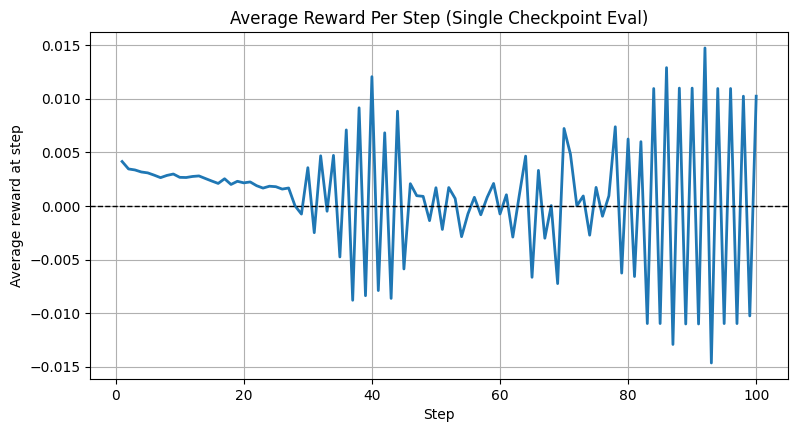

Plotted 100 steps. Last-step sample count: 2


In [11]:
import matplotlib.pyplot as plt

# --------------------------
# Single-checkpoint test
# --------------------------
dataset_path = "tet_dataset_grid125_sigma1e-02_N2000.mat"
ckpt_path = "out/03-22-16-26/model_round179.pt"

num_test = 10
seed = 0

score_mode = "softmin"   # "softmin" or "worstk"
softmin_tau = 0.05
worstk_k = 10

patience_eval = 25
max_steps = 100
greedy = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Load dataset
ds = TetMat73Dataset(dataset_path, load_all=False)
print("dataset size:", ds.num_samples)
T_good = ds.T_good

rng = np.random.default_rng(seed)
test_ids = rng.integers(0, ds.num_samples, size=num_test)

# Evaluate one model
result = evaluate_checkpoint(
    ckpt_path,
    ds,
    test_ids,
    T_good,
    device,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
)

# Print requested summary fields
print()
print("bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean")
print(
    f"{result['bad_mean']:+.6f}  "
    f"{result['final_mean']:+.6f}  "
    f"{result['best_mean']:+.6f}  "
    f"{result['good_mean']:+.6f}  "
    f"{result['improve_best']:+.6f}  "
    f"{result['gap_to_good']:+.6f}  "
    f"{result['steps_mean']:.2f}"
)

# Plot average reward at each step index across test samples
step_reward_mean = result["step_reward_mean"]
step_reward_count = result["step_reward_count"]

if step_reward_mean.size == 0:
    print("No step rewards to plot (agent took 0 actions on all test samples).")
else:
    x = np.arange(1, step_reward_mean.size + 1)
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, step_reward_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True)
    plt.xlabel("Step")
    plt.ylabel("Average reward at step")
    plt.title("Average Reward Per Step (Single Checkpoint Eval)")
    plt.show()

    print(f"Plotted {step_reward_mean.size} steps. Last-step sample count: {int(step_reward_count[-1])}")

ds.close()

In [12]:
@torch.inference_mode()
def run_agent_trace_episode(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
):
    topo = TetMeshTopology(P, T_init.copy())

    bad_q = topo.tet_quality.copy()
    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
    best = cur
    best_q = topo.tet_quality.copy()
    best_step = -1

    no_improve = 0
    steps = 0
    action_log = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        if a_env < F:
            op_type = "face (2-3)"
            op_local_index = int(a_env)
        else:
            op_type = "edge (3-2)"
            op_local_index = int(a_env - F)

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        delta = float(cur - prev)

        action_log.append(
            dict(
                step=int(steps),
                op_type=op_type,
                op_local_index=op_local_index,
                env_action=int(a_env),
                model_action=int(a_model),
                valid=bool(ok),
                score_before=float(prev),
                score_after=float(cur),
                delta=delta,
            )
        )

        if ok and (cur - best) >= eps_improve:
            best = cur
            best_q = topo.tet_quality.copy()
            best_step = steps
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    final_q = topo.tet_quality.copy()
    return dict(
        action_log=action_log,
        bad_q=bad_q,
        best_q=best_q,
        final_q=final_q,
        best_score=float(best),
        final_score=float(cur),
        steps=int(steps),
        best_step=int(best_step),
    )

device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
episode_id: 7

Episode summary
steps=56  best_step=30  final_score=+0.275682  best_score=+0.286782

Action trace (one line per step):
step | op_type      | local_idx | env_action | model_action | valid | delta_score
   0 | edge (3-2)   |       156 |       1110 |          156 | True  | +0.004804
   1 | edge (3-2)   |        92 |       1044 |           92 | True  | +0.003102
   2 | edge (3-2)   |       229 |       1179 |          229 | True  | +0.002303
   3 | edge (3-2)   |       293 |       1241 |          293 | True  | +0.002200
   4 | edge (3-2)   |       157 |       1103 |          157 | True  | +0.002495
   5 | edge (3-2)   |       186 |       1130 |          186 | True  | +0.002705
   6 | edge (3-2)   |       146 |       1088 |          146 | True  | +0.002148
   7 | edge (3-2)   |       337 |       1277 |          337 | True  | +0.002151
   8 | edge (3-2)   |       338 |       1276 |          338 | True  | +0.001380
   9 |

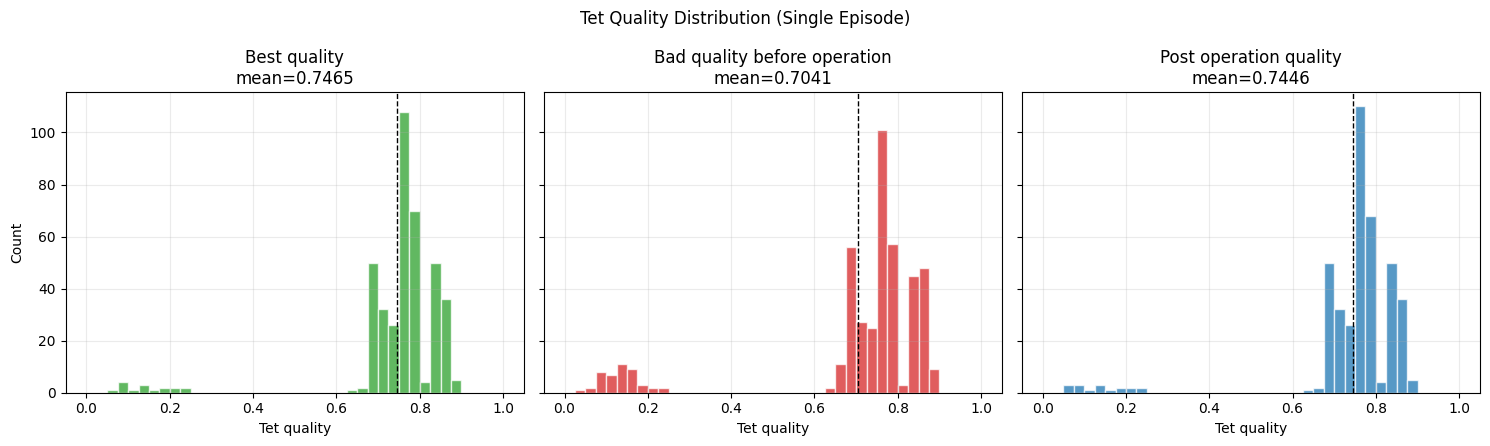

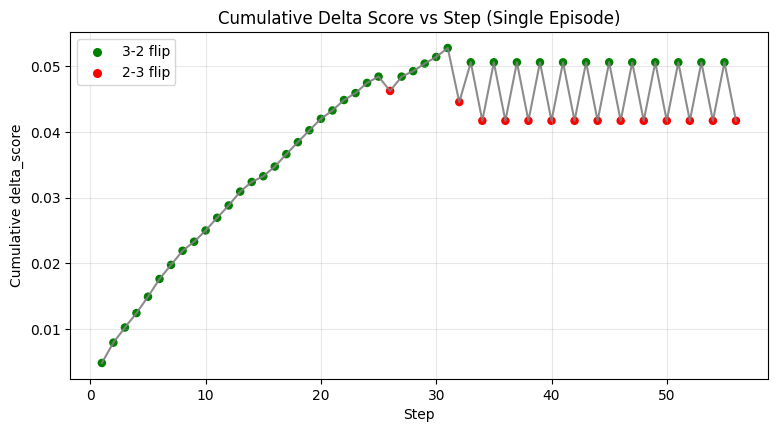

In [22]:
# -----------------------------------------
# Single-episode trace + quality histograms
# -----------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

# choose one episode id from dataset
episode_id = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("episode_id:", episode_id)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

ds = TetMat73Dataset(dataset_path, load_all=False)
if not (0 <= int(episode_id) < ds.num_samples):
    raise ValueError(f"episode_id must be in [0, {ds.num_samples-1}]")

P, Tbad = ds.get(int(episode_id))

# build model using this episode as shape example
topo0 = TetMeshTopology(P, Tbad)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

trace = run_agent_trace_episode(
    P,
    Tbad,
    model,
    device,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
)

print()
print("Episode summary")
print(f"steps={trace['steps']}  best_step={trace['best_step']}  final_score={trace['final_score']:+.6f}  best_score={trace['best_score']:+.6f}")

print()
print("Action trace (one line per step):")
print("step | op_type      | local_idx | env_action | model_action | valid | delta_score")
for a in trace["action_log"]:
    print(
        f"{a['step']:4d} | {a['op_type']:<12} | {a['op_local_index']:9d} | "
        f"{a['env_action']:10d} | {a['model_action']:12d} | {str(a['valid']):5s} | {a['delta']:+.6f}"
    )

# Histograms: best / bad-before / post-operation
best_q = trace["best_q"]
bad_q = trace["bad_q"]
final_q = trace["final_q"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality", best_q, "tab:green"),
    ("Bad quality before operation", bad_q, "tab:red"),
    ("Post operation quality", final_q, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Single Episode)")
plt.tight_layout()
plt.show()

# Cumulative delta_score vs step (green: 3-2, red: 2-3)
action_log = trace["action_log"]
if len(action_log) == 0:
    print("No actions taken; skip cumulative delta_score plot.")
else:
    steps = np.arange(1, len(action_log) + 1)
    deltas = np.array([float(a["delta"]) for a in action_log], dtype=np.float64)
    cum_delta = np.cumsum(deltas)

    colors = ["green" if "3-2" in a["op_type"] else "red" for a in action_log]

    plt.figure(figsize=(9, 4.5))
    plt.plot(steps, cum_delta, color="gray", linewidth=1.5, alpha=0.9)
    plt.scatter(steps, cum_delta, c=colors, s=26)

    # Legend handles
    plt.scatter([], [], c="green", s=30, label="3-2 flip")
    plt.scatter([], [], c="red", s=30, label="2-3 flip")

    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Cumulative delta_score")
    plt.title("Cumulative Delta Score vs Step (Single Episode)")
    plt.legend()
    plt.show()

ds.close()




In [ ]:
# -------------------------------------------------
# Multi-episode aggregate histograms + avg cum score
# -------------------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

num_eval_episodes = 50
seed_multi = 123

# Optional: set explicit episode ids; keep None to random sample.
episode_ids = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("num_eval_episodes:", num_eval_episodes)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

ds = TetMat73Dataset(dataset_path, load_all=False)

if episode_ids is None:
    rng = np.random.default_rng(seed_multi)
    replace = num_eval_episodes > ds.num_samples
    episode_ids = rng.choice(ds.num_samples, size=num_eval_episodes, replace=replace)
else:
    episode_ids = np.asarray(episode_ids, dtype=np.int64)

# Build model once using the first selected sample as shape example.
first_id = int(episode_ids[0])
P0, Tbad0 = ds.get(first_id)
topo0 = TetMeshTopology(P0, Tbad0)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

all_bad_q = []
all_best_q = []
all_final_q = []
cum_trajs = []

for eid in tqdm(episode_ids, desc="Aggregate eval", leave=False):
    P, Tbad = ds.get(int(eid))
    tr = run_agent_trace_episode(
        P,
        Tbad,
        model,
        device,
        score_mode=score_mode,
        softmin_tau=softmin_tau,
        worstk_k=worstk_k,
        patience_eval=patience_eval,
        max_steps=max_steps,
        greedy=greedy,
    )

    all_bad_q.append(tr["bad_q"])
    all_best_q.append(tr["best_q"])
    all_final_q.append(tr["final_q"])

    deltas = np.array([float(a["delta"]) for a in tr["action_log"]], dtype=np.float64)
    cum = np.cumsum(deltas) if deltas.size > 0 else np.zeros((0,), dtype=np.float64)
    cum_trajs.append(cum)

# Concatenate all tet qualities across episodes
bad_q_all = np.concatenate(all_bad_q) if len(all_bad_q) > 0 else np.zeros((0,), dtype=np.float64)
best_q_all = np.concatenate(all_best_q) if len(all_best_q) > 0 else np.zeros((0,), dtype=np.float64)
final_q_all = np.concatenate(all_final_q) if len(all_final_q) > 0 else np.zeros((0,), dtype=np.float64)

print()
print("Aggregate quality stats")
print(f"episodes={len(episode_ids)}")
print(f"bad_mean={bad_q_all.mean():.6f}  best_mean={best_q_all.mean():.6f}  final_mean={final_q_all.mean():.6f}")

# Plot three histograms (all tets from all selected episodes)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (all episodes)", best_q_all, "tab:green"),
    ("Bad quality before operation (all episodes)", bad_q_all, "tab:red"),
    ("Post operation quality (all episodes)", final_q_all, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Aggregated Across Episodes)")
plt.tight_layout()
plt.show()

# Average cumulative score change vs step
max_len = max((len(c) for c in cum_trajs), default=0)
if max_len == 0:
    print("No actions taken in all selected episodes; skip cumulative plot.")
else:
    cum_mean = np.full(max_len, np.nan, dtype=np.float64)
    cum_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [c[t] for c in cum_trajs if t < len(c)]
        if vals:
            cum_mean[t] = float(np.mean(vals))
            cum_count[t] = int(len(vals))

    x = np.arange(1, max_len + 1)
    plt.figure(figsize=(9.5, 4.8))
    plt.plot(x, cum_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Average cumulative delta_score")
    plt.title("Average Cumulative Score Change vs Step (Aggregated Episodes)")
    plt.show()

    print(f"Cumulative curve length: {max_len} steps")
    print(f"Last-step contributor count: {int(cum_count[-1])}")

ds.close()

